# Movie Recommendation for Streaming Platform
## Notebook 2 — Visualizations

**Objective:** Draw insights from the merged dataset through charts and plots.

Run `1_EDA.ipynb` first to generate `merged_data.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

In [2]:
# Load merged data
data = pd.read_csv(r'C:\Movie Recommendation project\data\merged_data.csv')

# Re-apply age group labels
age_map = {1:'Under 18', 18:'18-24', 25:'25-34', 35:'35-44', 45:'45-49', 50:'50-55', 56:'56+'}
data['age_group'] = data['age'].map(age_map)

occupation_dict = {
    0:'Other', 1:'Academic/Educator', 2:'Artist', 3:'Clerical/Admin',
    4:'College/Grad Student', 5:'Customer Service', 6:'Doctor/Health Care',
    7:'Executive/Managerial', 8:'Farmer', 9:'Homemaker', 10:'K-12 Student',
    11:'Lawyer', 12:'Programmer', 13:'Retired', 14:'Sales/Marketing',
    15:'Scientist', 16:'Self-Employed', 17:'Technician/Engineer',
    18:'Tradesman/Craftsman', 19:'Unemployed', 20:'Writer'
}
data['occupation_name'] = data['occupation'].map(occupation_dict)

print('Data loaded:', data.shape)

Data loaded: (1000209, 12)


## Plot 1 — Rating Distribution
How are ratings spread across 1–5? This tells us whether users tend to rate positively or negatively.

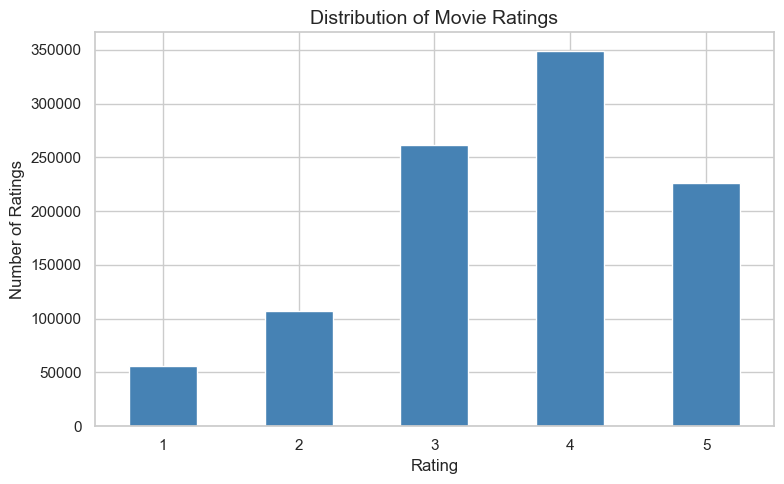

Rating value counts:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(8, 5))
data['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Rating value counts:')
print(data['rating'].value_counts().sort_index())

## Plot 2 — Top 20 Most-Rated Movies
Which movies have received the most ratings? (Popularity by volume, not by score.)

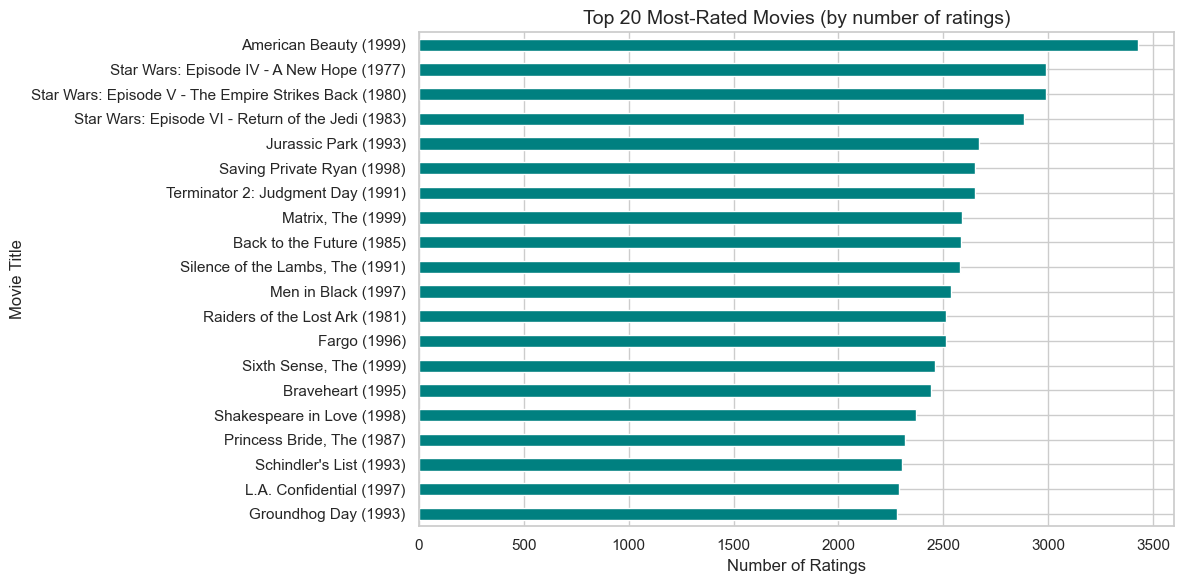

In [4]:
top_rated_count = data.groupby('title')['rating'].count().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top_rated_count.sort_values().plot(kind='barh', color='teal', edgecolor='white')
plt.title('Top 20 Most-Rated Movies (by number of ratings)')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

## Plot 3 — Top 20 Highest Average-Rated Movies
Which movies have the highest average rating? (Filter to movies with ≥ 50 ratings to avoid noise from obscure films.)

C:\Users\HP\AppData\Local\Temp\ipykernel_11876\2044258307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_avg, y='title', x='avg_rating', palette='Blues_r')


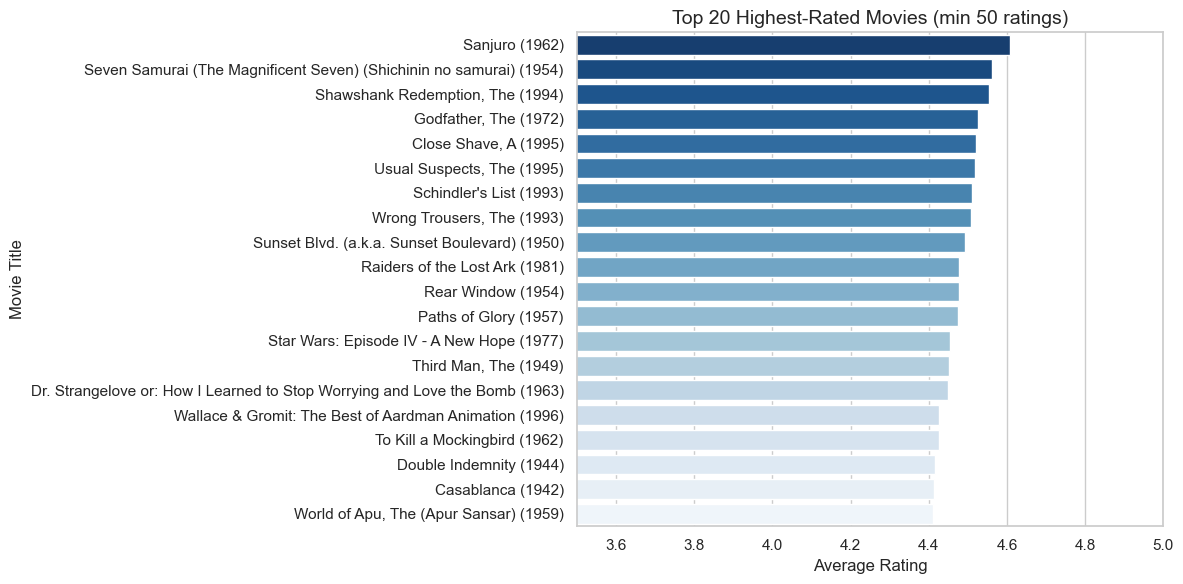

In [5]:
movie_stats = data.groupby('title')['rating'].agg(['mean', 'count']).reset_index()
movie_stats.columns = ['title', 'avg_rating', 'num_ratings']

# Filter: at least 50 ratings so the average is meaningful
popular_movies = movie_stats[movie_stats['num_ratings'] >= 50]
top_avg = popular_movies.sort_values('avg_rating', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_avg, y='title', x='avg_rating', palette='Blues_r')
plt.title('Top 20 Highest-Rated Movies (min 50 ratings)')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.show()

## Plot 4 — Average Rating by Gender
Do male and female users rate movies differently?

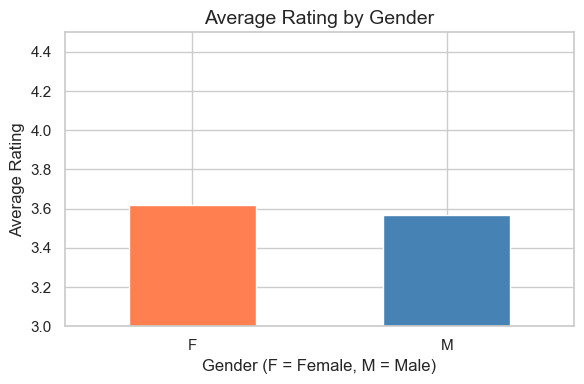

gender
F    3.620366
M    3.568879
Name: rating, dtype: float64


In [6]:
gender_rating = data.groupby('gender')['rating'].mean()

plt.figure(figsize=(6, 4))
gender_rating.plot(kind='bar', color=['coral', 'steelblue'], edgecolor='white')
plt.title('Average Rating by Gender')
plt.xlabel('Gender (F = Female, M = Male)')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.ylim(3.0, 4.5)
plt.tight_layout()
plt.show()

print(gender_rating)

## Plot 5 — Number of Ratings by Age Group
Which age group is most active on the platform?

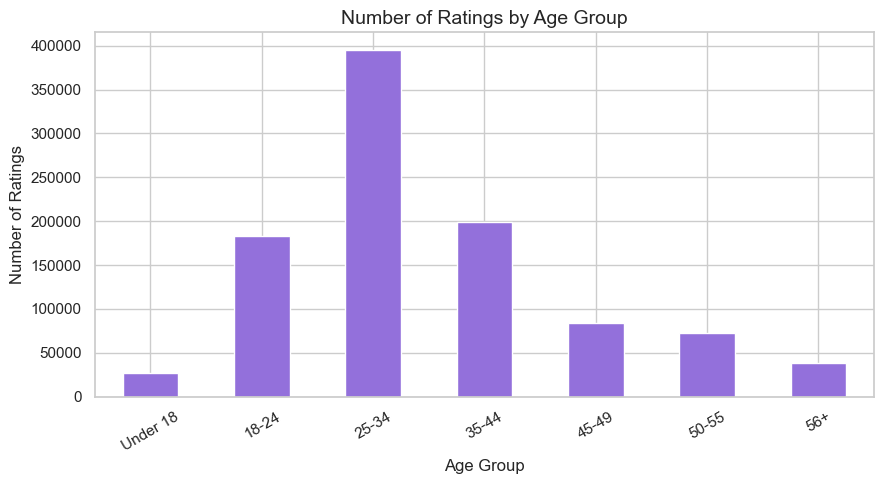

In [7]:
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
age_counts = data.groupby('age_group')['rating'].count().reindex(age_order)

plt.figure(figsize=(9, 5))
age_counts.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Number of Ratings by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Plot 6 — Average Rating by Age Group
Does age influence how critically users rate movies?

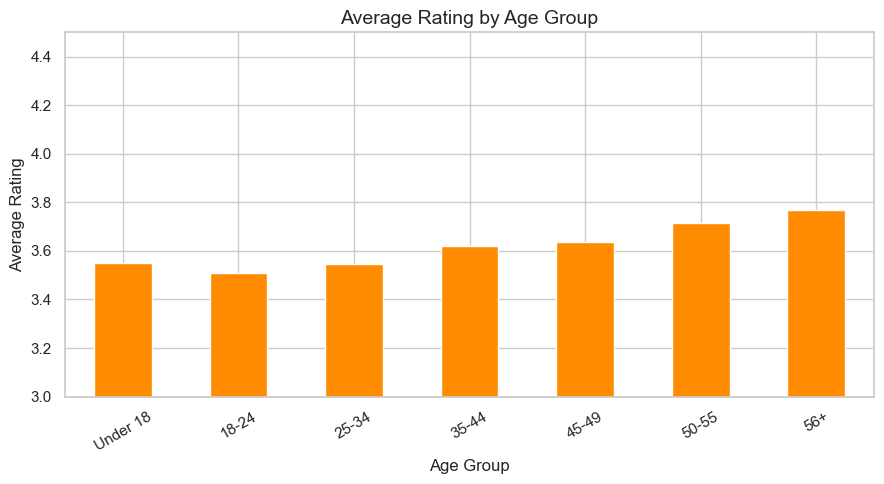

In [8]:
age_avg_rating = data.groupby('age_group')['rating'].mean().reindex(age_order)

plt.figure(figsize=(9, 5))
age_avg_rating.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Average Rating by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Rating')
plt.xticks(rotation=30)
plt.ylim(3.0, 4.5)
plt.tight_layout()
plt.show()

## Plot 7 — Most Popular Genres
Which genres appear most in the dataset? (One movie can have multiple genres.)

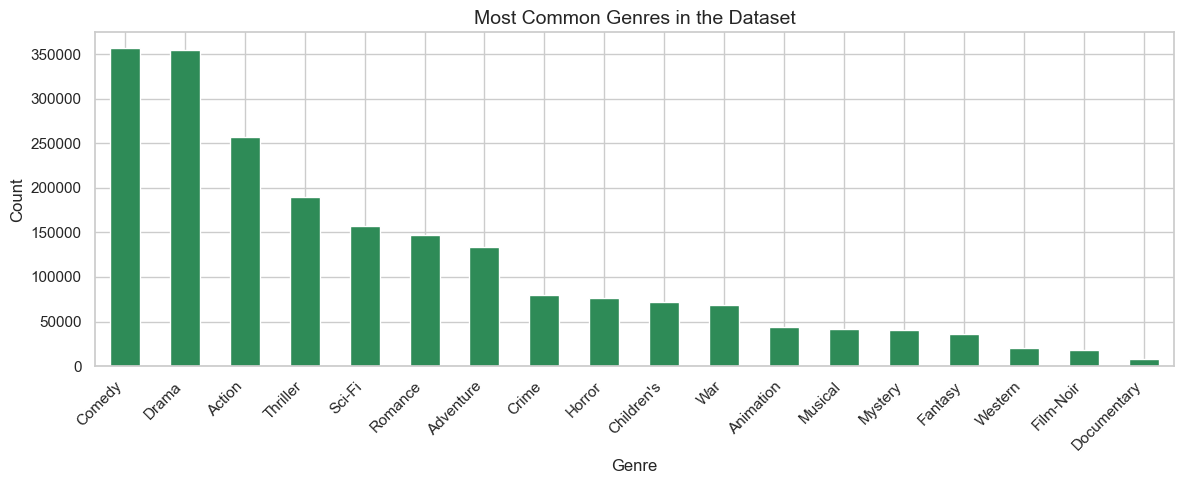

In [9]:
# Each movie can have multiple genres separated by '|'
genre_series = data['genres'].dropna().str.split('|').explode()
genre_counts = genre_series.value_counts()

plt.figure(figsize=(12, 5))
genre_counts.plot(kind='bar', color='seagreen', edgecolor='white')
plt.title('Most Common Genres in the Dataset')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Plot 8 — Average Rating per Genre
Which genres tend to get rated highest?

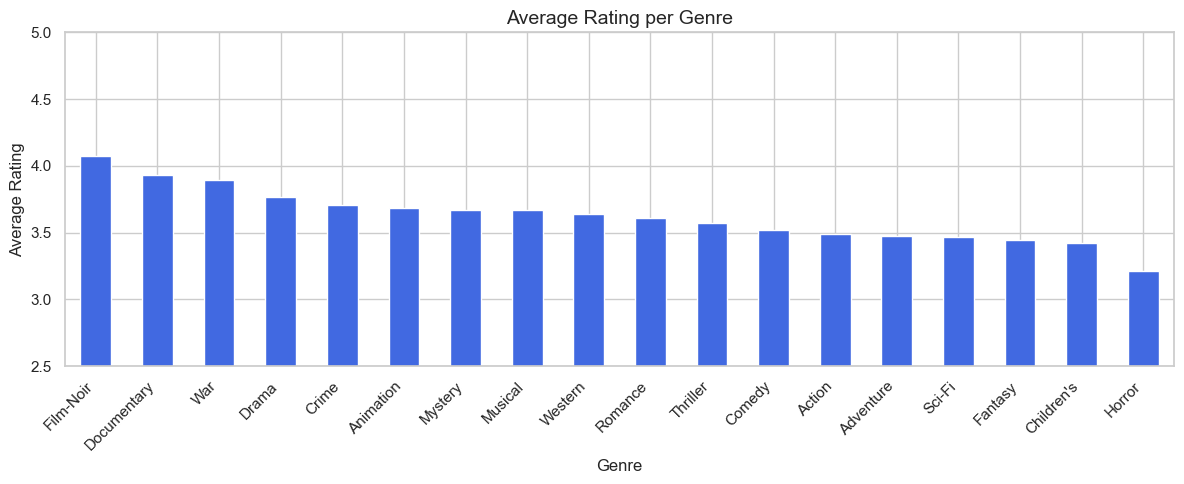

In [10]:
# Explode genres and keep rating column alongside
genre_rating_df = data[['genres', 'rating']].copy()
genre_rating_df = genre_rating_df.assign(genre=genre_rating_df['genres'].str.split('|')).explode('genre')

genre_avg = genre_rating_df.groupby('genre')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
genre_avg.plot(kind='bar', color='royalblue', edgecolor='white')
plt.title('Average Rating per Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.ylim(2.5, 5.0)
plt.tight_layout()
plt.show()

## Plot 9 — User Activity Distribution
How many movies does an average user rate? Are most users light or heavy raters?

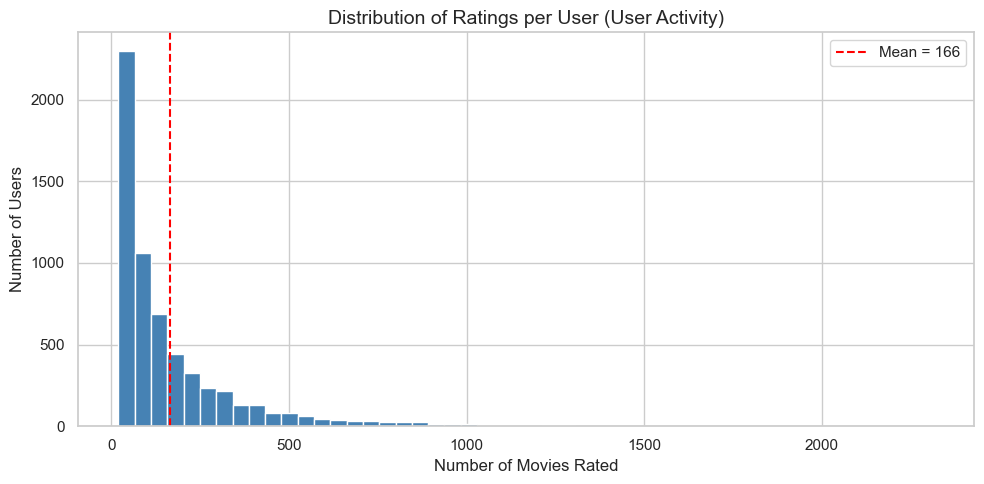

Min ratings by a user : 20
Max ratings by a user : 2314
Mean ratings per user : 165.6


In [11]:
user_activity = data.groupby('user_id')['rating'].count()

plt.figure(figsize=(10, 5))
plt.hist(user_activity, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Ratings per User (User Activity)')
plt.xlabel('Number of Movies Rated')
plt.ylabel('Number of Users')
plt.axvline(user_activity.mean(), color='red', linestyle='--', label=f'Mean = {user_activity.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Min ratings by a user : {user_activity.min()}')
print(f'Max ratings by a user : {user_activity.max()}')
print(f'Mean ratings per user : {user_activity.mean():.1f}')

## Plot 10 — Top 10 Most Active Users
Who are the heaviest raters on the platform?

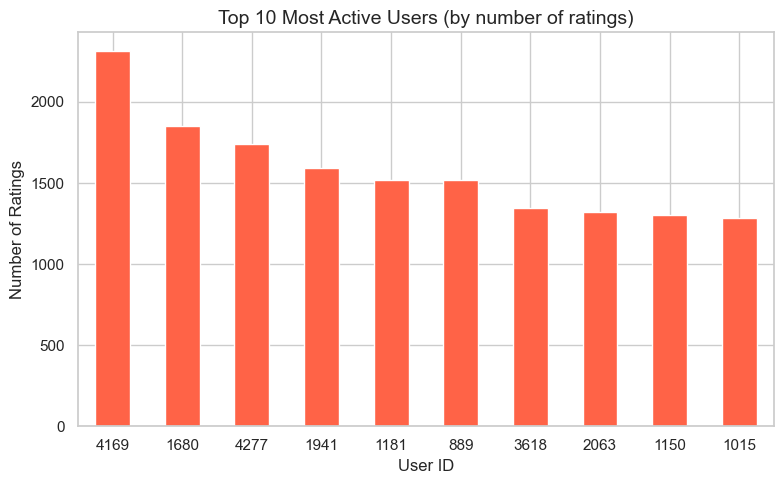

In [12]:
top_users = user_activity.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_users.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 10 Most Active Users (by number of ratings)')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Plot 11 — Average Rating by Occupation
Do users from different occupations rate movies differently?

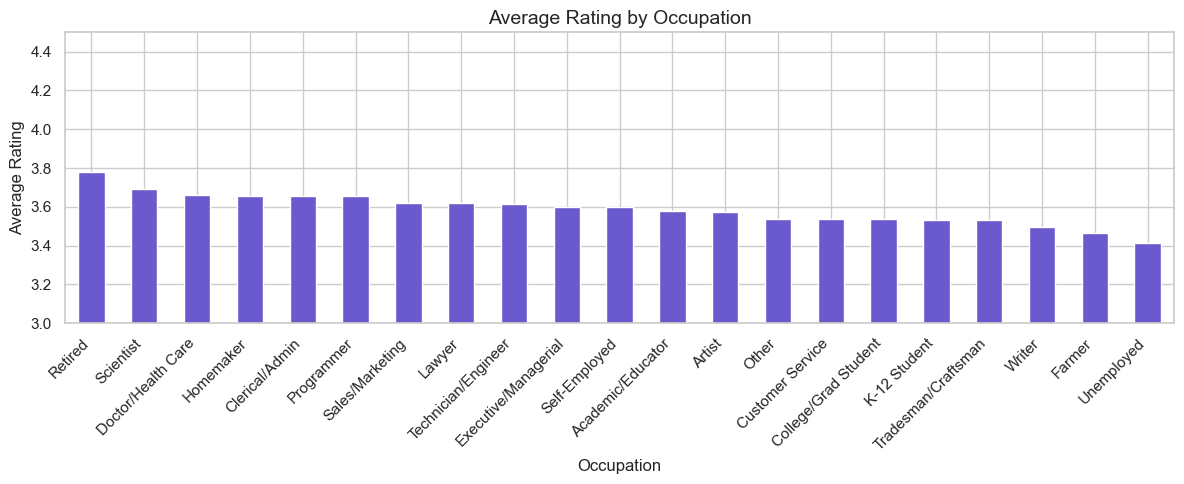

In [13]:
occ_avg = data.groupby('occupation_name')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
occ_avg.plot(kind='bar', color='slateblue', edgecolor='white')
plt.title('Average Rating by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.ylim(3.0, 4.5)
plt.tight_layout()
plt.show()

## Visualization Summary — Key Insights

| Plot | Insight |
|---|---|
| Rating distribution | Most users rate 3–4; very few give 1s |
| Most-rated movies | Blockbusters dominate (Star Wars, Jurassic Park) |
| Highest avg-rated | Classic films score highest among active raters |
| Gender | Male and female users rate similarly on average |
| Age group | 25–34 is the most active rating group |
| Genres | Drama and Comedy are most common; Film-Noir rates highest |
| User activity | Most users rate fewer than 100 movies; a few rate 1000+ |
| Occupation | Rating behaviour varies only slightly across occupations |